# Introduction

This notebook is designed to provide an accesible platform for analyzing sequencing data. This notebook allows you to perfom analysis wihtout the need to dowload or install any additional software. You only need is a Google account.

You will need the following files:
* Feature table
* Taxonomy table
* Phylogenetic Tree
* Sample metadata

Before starting the analysis, we need to mount our Google Drive in this notebook. This step is crucial because it allows us to save output files directly to the Google drive. If you don't perform this step, any files created during the session will be lost once the Colab environment is reset.
In this section, we install the rpy2 library. This setup allows us to run R scripts directly within the notebook, enabling the integration of R’s statistical capabilities with Python’s environment.

In [ ]:
import subprocess

# Install Conda via condacolab
subprocess.run(["pip", "install", "-q", "condacolab"], check=True)

# Import and install Conda using condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install rpy2
%load_ext rpy2.ipython
!git clone https://github.com/stijnteunissen/Workshop_H2Omics_test.git

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'Workshop_H2Omics_test' already exists and is not an empty directory.


deze code blok laad de juiste bestanden in vanuit de output folder van jippe of vanuit eigen drive als jippe zijn deel niet is uitgevoerd


# Analysis Preparation
### Creating the Output Folder

This code block constructs a folder path by combining the base path (`"drive/MyDrive/"`) with your project name, and then creates that directory. This folder will be used to store all output files generated during the analysis, ensuring they are organized and safely saved in your Google Drive.

In [ ]:
import sys
sys.path.append("/content/Workshop_H2Omics_test/H2Omics_analysis")

from starting_project import starting_project

starting_project()

Main folder 'H2Omics_data_analysis' already exists.


Dropdown(description='Project:', options=('Test_20250331', 'Test_20250402', 'test_20250403', 'Test_20250404', …

Text(value='', description='New Project Name:', layout=Layout(display='none'), placeholder='Enter project name…

Button(description='Confirm Project', style=ButtonStyle())

Output()

gebruiken als er eigen qza files ingeladen moeten worden en ook altijd gebruiken om de clasefier in te laden .qza


### Loading Input Files

In this section, you will be prompted to upload the necessary files from your local computer. These files are essential for the analysis and should include:

- **Feature Table:** Contains the abundance data of various features (e.g., OTUs or ASVs) across your samples.
- **Taxonomy Table:** Provides the taxonomic assignments for each feature.
- **Phylogenetic Tree:** Represents the evolutionary relationships among the detected features.
- **Sample Metadata:** Includes detailed information about each sample,


Uploading these files allows the notebook to integrate all the required data for a comprehensive analysis of your sequencing dataset.

In [ ]:
import sys
sys.path.append("/content/Workshop_H2Omics_test/H2Omics_analysis")

from import_files import import_files

import_files()

Retrieved from R - Project: test_20250407, Base Path: drive/MyDrive/H2Omics_data_analysis/test_20250407/r_visualisation/


Files have been successfully moved to: drive/MyDrive/H2Omics_data_analysis/test_20250407/r_visualisation/test_20250407/qiime2_output


Dropdown(description='Method:', options=('Galaxy Classification', 'Not Galaxy Classification'), value='Galaxy …

Button(description='Continue Script', style=ButtonStyle())

Output()

# Installing and Loading R Packages

In this section, we install and load all the required R packages for performing the sequencing data analysis. These commands ensure that every package needed for the analysis is automatically downloaded and loaded into the current R session.

In [ ]:
import sys
sys.path.append("/content/Workshop_H2Omics_test/H2Omics_analysis")

from install_conda import install_conda

install_conda()

Installation completed successfully!


In [ ]:
%%R
source("/content/Workshop_H2Omics_test/H2Omics_analysis/install_packages.R")

install_packages()

All packages have been installed and loaded.


In [ ]:
%%R
#@markdown ##### Choose the type of factors used for analysis.
present_variable_factors = "batch, sample_type" #@param {type: "string"}

factors <- unlist(strsplit(present_variable_factors, ","))
factors <- trimws(factors)
present_variable_factors <- c(factors)

# Starting the analysis


In [ ]:
%%R
source("/content/Workshop_H2Omics_test/H2Omics_analysis/copy_number_prediction.R")

copy_number_prediction()

[1] "hmmalign --trim --dna -o RasperGade16S_align//seq.align --mapali /content/Workshop_H2Omics_test/H2Omics_analysis/Rlibs/RasperGade16S/extdata/aligned_remove_dot.fasta /content/Workshop_H2Omics_test/H2Omics_analysis/Rlibs/RasperGade16S/extdata/16S_core_gg.hmm drive/MyDrive/H2Omics_data_analysis/test_20250407/r_visualisation//test_20250407/qiime2_output/dna-sequences.fasta"
[1] "esl-reformat -o RasperGade16S_align//seq.afa -u --gapsym=- afa RasperGade16S_align//seq.align"
[1] "epa-ng -t /content/Workshop_H2Omics_test/H2Omics_analysis/Rlibs/RasperGade16S/extdata/reference.tre -s /content/Workshop_H2Omics_test/H2Omics_analysis/Rlibs/RasperGade16S/extdata/reference.trimmed.afa -q RasperGade16S_align/trimmed.afa --model /content/Workshop_H2Omics_test/H2Omics_analysis/Rlibs/RasperGade16S/extdata/reference.RAxML.model.txt --preserve-rooting on --outdir RasperGade16S_EPA/ --redo --filter-max 99"
2919 unique partitions found.
Formatting insert location information
Insert locations parsed.
Co

File copied and renamed to: drive/MyDrive/H2Omics_data_analysis/test_20250407/r_visualisation//test_20250407/qiime2_output/test_20250407_copy_number_prediction.RDS


### Creating a Logging System

This block creates a directory named "messages" if it doesn’t already exist. It then defines a log file (logging_output.txt) where all analysis steps will be recorded. The log_message function logs each step with a timestamp.

In [ ]:
%%R
if(!dir.exists(paste0(base_path, projects, "/messages"))){dir.create(paste0(base_path, projects, "/messages"))}
log_file = paste0(base_path, glue("{projects}/messages/logging_output.txt"))

log_message = function(message, log_file) {
  write(paste(format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "-", message), log_file, append = TRUE)
}

### Setting up the project structure

This function creates a folder structure for projects, ensuring that
all necessary directories exist and that specific files required for downstream analysis are copied from the `qiime2_output` folder into the `input_data` folder.

In [ ]:
%%R
# create folders and copy files
micromics::create_folders(projects)

### Merging Metadata

This function merges and formats metadata, including
QIIME metadata, experimental sample metadata and qPCR data or FCM data, to create a unified metadata file for downstream analyses.

In [ ]:
%%R
log_message(paste("Step 1: Merge metadata: adding fcm or qpcr data to the original metadata.", paste(projects, collapse = ", ")), log_file)

# combine qiime2 metadata with experimental sampled metadata
unified_metadata = micromics::unify_metadata(projects)

log_message("Metadata successfully merged.", log_file)

### Creating the phyloseq object

Phyloseq object is a R data structure. Including feature table, taxonomy, phylogenetic tree and unified metadata into a single coherent dataset for streamlined analysis. this funciton creates a `phyloseq` object.


In [ ]:
%%R
log_message(paste("Step 2: Creating phyloseq object (physeq): is created using the table, rooted tree, classifier and metadata.", paste(projects, collapse = ", ")), log_file)

# create a physeq object
physeq = micromics::creating_physeq_object(projects)

log_message("Phyloseq successfully created.", log_file)

Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
A

### Tax clean
This function cleans and filters the taxonomy table within a `phyloseq` object. It removes unclassified or ambiguous names, and replaces these and missing taxon names at genus level with placeholders derived from higher
taxonomic ranks.

`tax_filer` (True or False) this function filters specific taxa (e.g., Eukaryota, chloroplasts, mitochondria, and ASVs unclassified at Kingdom and Phylum levels).
The cleaned taxonomy enables taxonomic agglomeration (`tax_glom`) to genus level without merging unclassified taxa from diverse ancestry.

In [ ]:
%%R
log_message(paste("Step 3: Tax clean: phyloseq taxa are cleand.", paste(projects, collapse = ", ")), log_file)

# tax clean
cleaned_physeq = micromics::tax_clean(physeq = physeq, tax_filter = TRUE)

log_message("Successfully Tax cleant.", log_file)

Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’


### Resolving the phylogenetic tree

This function processes a `phyloseq` object to resolve multichotomies (non-binary nodes) in the phylogenetic tree using the `ape` package. This is inmportant for accurate evolutionary analysis. It ensures the tree is binary and saves the updated `phyloseq` object as an RDS file.

In [ ]:
%%R
log_message(paste("Step 4: Resolving tree.", paste(projects, collapse = ", ")), log_file)

# Resolve polytomous branching of the QIIME2 Fasttree2 phylogeny into a fully bifurcated tree for phylogenetic analyses
resolved_tree_physeq = micromics::resolve_tree(physeq = cleaned_physeq)

log_message("Tree successfully resolved", log_file)

Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’


### Removing contaminats

This function removes contamination from a phyloseq object using either
frequency, prevalence, or both methods.

It first checks for blank samples and processes the contamination based on the specified method.

The function also generates and saves plots showing the read counts and prevalence of contaminants.

In [ ]:
%%R
#@markdown ##### Contamination removla method, If no blank samples are present in the dataset, use `frequency`
decon_method = "both" #@param {type: "string"} ["prevalence", "frequency", "both"]

#@markdown ##### Blank sample presence, Set to TRUE if blank samples are included in the dataset, FALSE if they are absent.
blank = TRUE # @param ["TRUE","FALSE"] {"type":"raw"}


[1] "test_20250407 - Method frequency:"

FALSE  TRUE 
 2265    11 
[1] "test_20250407 - Method prevalence:"

FALSE  TRUE 
 2219    57 
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
Also defined by ‘tidytree’
Found more than one class "phylo" in cache; using the first, from namespace 'phyloseq'
A

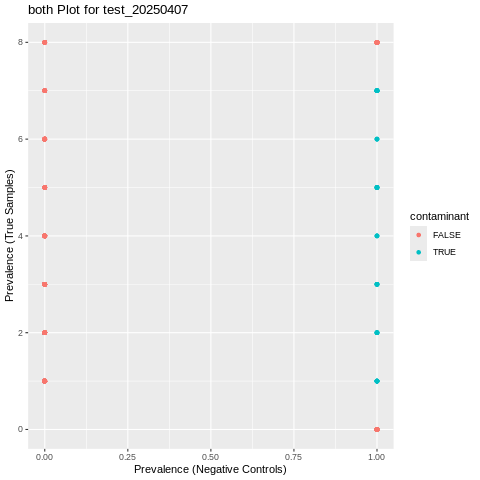

In [ ]:
%%R
log_message(paste("Step 6: Decontam: Removing contamination.", paste(projects, collapse = ", ")), log_file)

# decontam (decon_method = frequency, prevalence or both)
decontam_physeq = micromics::decontam(physeq = resolved_tree_physeq, decon_method = decon_method, blank = blank)

log_message("Decontam successfully executed.", log_file)

### Removing Mock community features

This function removes mock ASVs (amplicon sequence variants) from a `phyloseq` object.
Mock ASVs are typically used for decontamination purposes and are identified by their genus names.
The function also filters the dataset to retain only samples with `sample_type == "sample`.
The user can choose whether to filter out the mock ASVs from the dataset by setting the `mock` parameter.

In [ ]:
%%R
log_message(paste("Step 7: Removing mock: Mock samples en mock OTUs are removed fropm phyloseq object.", paste(projects, collapse = ", ")), log_file)

# remove mock and mock features
without_mock_physeq = micromics::remove_mock(physeq = decontam_physeq, mock = TRUE,
mock_genera = c("Massilia", "Serratia", "Vulgatibacter", "Brevibacillus", "Lysinibacillus",
                "Weizmannia", "Streptomyces", "Bacillus", "Peribacillus", "Bordetella",
                "Sphingobium", "Burkholderia-Caballeronia-Paraburkholderia",
                "Genus of Bacilli", "Genus of Bacillaceae", "Genus of Bacillales",
                "Genus of Planococcaceae", "Genus of Burkholderiaceae",
                "Genus of Burkholderiales", "Genus of Yersiniaceae"))

log_message("Mock successfully removed.", log_file)

Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'physeq' in selecting a method for function 'taxa_names': error in evaluating the argument 'table' in selecting a method for function '%in%': object 'mock_genera' not found


RInterpreterError: Failed to parse and evaluate line 'log_message(paste("Step 7: Removing mock: Mock samples en mock OTUs are removed fropm phyloseq object.", paste(projects, collapse = ", ")), log_file)\n\n# remove mock and mock features\nwithout_mock_physeq = micromics::remove_mock(physeq = decontam_physeq, mock = TRUE,\nmock_genera = c("Massilia", "Serratia", "Vulgatibacter", "Brevibacillus", "Lysinibacillus",\n                "Weizmannia", "Streptomyces", "Bacillus", "Peribacillus", "Bordetella",\n                "Sphingobium", "Burkholderia-Caballeronia-Paraburkholderia",\n                "Genus of Bacilli", "Genus of Bacillaceae", "Genus of Bacillales",\n                "Genus of Planococcaceae", "Genus of Burkholderiaceae",\n                "Genus of Burkholderiales", "Genus of Yersiniaceae"))\n\nlog_message("Mock successfully removed.", log_file)\n'.
R error message: "Error in h(simpleError(msg, call)) : \n  error in evaluating the argument 'physeq' in selecting a method for fu

### Copy number correction and biomass normalisation

This function applies normalization to a `phyloseq` object, allowing the
conversion of data to absolute values based on biomass data form either flow cytometry (FCM) or qPCR.

This function begins with a copy number correction. This step is essential because the 16S rRNA gene can occur in multiple copies within a single genus, which may lead to an overestimation of its abundance. After the copy number correction, a biomass correction is applied. This adjustment accounts for the biomass of each sample, ensuring that the final abundance values accurately reflect the true microbial composition.

In [ ]:
%%R
#@markdown ##### Choose the type of data for normalisation.
norm_method = "fcm" #@param {type: "string"} ["NULL", "fcm", "qpcr"]

#@markdown ##### copy number correction
copy_correction = TRUE # @param ["TRUE","FALSE"] {"type":"raw"}

In [ ]:
%%R
log_message(paste("Step 8: copy number correction for relative data and biomass normalisation for absolute data.", paste(projects, collapse = ", ")), log_file)

# copy number correction and biomasss normalisation
normalised_asv_physeq = micromics::normalise_data(physeq = without_mock_physeq, norm_method = norm_method, copy_correction = copy_correction)

log_message("Anna16 correction and fcm or qpcr normalisation successfully modified.", log_file)

### Rarefaction

This function performs rarefaction on a normalized `phyloseq` object. Rarefaction is based on the biomass of each sample to identify the minimum sampling depth across the dataset. By rarefying all samples to this sampling depth, we ensure that the data are normalized for sequencing effort. This step prevents an overestimation of genus abundance in samples with higher sequencing depths, allowing for more accurate and comparable results.

In [ ]:
%%R
log_message(paste("Step 10: rarefied data", paste(projects, collapse = ", ")), log_file)

# rarefied data
rarefied_asv_physeq = micromics::rarefying(physeq = normalised_asv_physeq, norm_method = norm_method, iteration = 10)

log_message("Data is successfully rarefied.", log_file)

### Grouping data by taxonomy level

This function aggregates a phyloseq object to higher taxonomic levels (e.g.,
Phylum, Class, Order, Family, or Tax_label) using the \code{tax_glom}
function. Depending on the specified normalization method, the function
processes and saves both copy number corrected data and normalized data (using
flow cytometry or qPCR) as RDS files in dedicated directories.

In [ ]:
%%R
log_message(paste("Step 11: Tax glom: OTUs are merged at different taxonomic levels.", paste(projects, collapse = ", ")), log_file)

rarefied_tax_physeq = micromics::group_tax(physeq = rarefied_asv_physeq, norm_method = norm_method)

log_message("Successfully Tax glom.", log_file)

### Converting Phyloseq object to Tibble

This function transforms a phyloseq object into a tibble for each specified taxonomic level using the
`psmelt` function from the `phyloseq` package.

In [ ]:
%%R
log_message(paste("Step 12: Convert phyloseq to tibble.", paste(projects, collapse = ", ")), log_file)

# converting phyloseq object to a tibble
rarefied_tax_psmelt = micromics::psdata_to_tibble(physeq = rarefied_tax_physeq, norm_method = norm_method)

log_message("Successfully converted", log_file)

### Creating a Barplot

This function generates barplots for microbial data at the genus level. It supports both relative and absolute abundance data and can include facets based on available metadata factors. The resulting plots can be saved as PDF files, and the underlying data can be exported as CSV and RDS files.

In [ ]:
%%R
#@markdown ##### Sample matrix type, "liquid" (for water samples) or "solid" (for soil samples)
sample_matrix = "liquid" #@param {type: "string"} ["liquid", "solid"]

In [ ]:
%%R
log_message(paste("Step 15: Creating barplot.", paste(projects, collapse = ", ")), log_file)

# Barplot
created_barplot = micromics::barplot(physeq = rarefied_tax_psmelt, ntaxa = 23, norm_method = norm_method,
                                     sample_matrix = sample_matrix, group_by_factor = NULL)

log_message("Barplot successfully plotted.", log_file)

### Creating a Heatmap

This function creates a heatmap of relative abundance data or absolute abundance data from the Tibble at the genus level. tax below a defined threshold are grouped together into an `other` category.


In [ ]:
%%R
log_message(paste("Step 16: making heatmap.", paste(projects, collapse = ", ")), log_file)

# heatmap
heatmap_plot = micromics::heatmap(physeq = rarefied_tax_psmelt, ntaxa = 23, norm_method = norm_method)

log_message("Heatmap successfully plotted.", log_file)

### Creating Alpha diverstiy plot

This function calculates alpha diversity metrics from a phyloseq object and
generates alpha diversity plots at various taxonomic levels or at the ASV
level. The alpha diversity measures (Observed, Chao1, Shannon, Simpson) are
computed using the `estimate_richness` function from the `phyloseq` package. Depending on the input parameters, the function can handle normalized data and can separate plots by DNA and RNA types.

In [ ]:
%%R
log_message(paste("Step 17: Making alpha diversity.", paste(projects, collapse = ", ")), log_file)

# alpha diversity

# asv level
alpha_div_plots = micromics::alpha_diversity(physeq = rarefied_asv_physeq, taxrank = "asv", norm_method = norm_method)

# genus level
alpha_div_plots = micromics::alpha_diversity(physeq = rarefied_tax_physeq, norm_method = norm_method)

log_message("Alpha diversity successfully plotted.", log_file)

### Creating Beta diversity

This function computes beta diversity using ordination methods PCoA on a phyloseq object and generates corresponding ordination plots. It supports both ASV-level data and data aggregated at various taxonomic levels, and it can handle both relative and, if available, absolute abundance data. Four distance metrics are used for relative abundance plots (Jaccard, Bray-Curtis, Unweighted UniFrac, and Weighted UniFrac), and Manhattan distance is used for absolute abundance plots when a normalization method is provided.


In [ ]:
%%R
#@markdown ##### Factors for beta diversity visualization, Specify a factor for coloring points, or set to NULL if unused.
color_factor = "sample_type" #@param {type: "string"}
if (color_factor == "NULL") {
  color_factor <- NULL
} else {
  color_factor <- color_factor
}

#@markdown ##### Factors for beta diversity visualization, Specify a factor for coloring points, or set to NULL if unused.
color_continuous = TRUE # @param ["TRUE","FALSE"] {"type":"raw"}

#@markdown ##### Additional factors for beta diversity visualization, or set to NULL if unused
shape_factor = "batch" #@param {type: "string"}
if (shape_factor == "NULL") {
  shape_factor <- NULL
} else {
  shape_factor <- shape_factor
}

size_factor = "NULL" #@param {type: "string"}
if (size_factor == "NULL") {
  size_factor <- NULL
} else {
  size_factor <- size_factor
}

alpha_factor = "NULL" #@param {type: "string"}
if (alpha_factor == "NULL") {
  alpha_factor <- NULL
} else {
  alpha_factor <- alpha_factor
}

#@markdown ##### date factor
date_factor = "NULL" #@param {type: "string"}
if (date_factor == "NULL") {
  date_factor <- NULL
} else {
  date_factor <- date_factor
}

In [ ]:
%%R
log_message(paste("Step 18: Making beta diversity.", paste(projects, collapse = ", ")), log_file)

# beta diversity

# asv level
beta_div_plots = micromics::beta_diversity(physeq = rarefied_asv_physeq, taxrank = "asv", norm_method = norm_method,
                                           ordination_method = "PCoA", color_factor = color_factor, color_continuous = color_continuous,
                                           shape_factor = shape_factor, size_factor = size_factor, alpha_factor = alpha_factor)

# genus level
beta_div_plots = micromics::beta_diversity(physeq = rarefied_tax_physeq, norm_method = norm_method,
                                           ordination_method = "PCoA", color_factor = color_factor, color_continuous = color_continuous,
                                           shape_factor = shape_factor, size_factor = size_factor, alpha_factor = alpha_factor)

log_message("Beta diversity successfully plotted.", log_file)

### Exporting data and figures

This function exports project-related figures and output data by creating a dedicated export folder within the project directory. It organises the export folder into subdirectories for figures, CSV files, and RDS files, copies the relevant files from their original locations.

In [ ]:
%%R
log_message(paste("Step 19: export figures and rds files.", paste(projects, collapse = ", ")), log_file)

# export data
micromics::export_data()

log_message("export completed.", log_file)